# 04 - Model Explainability with SHAP

## Goal
Make our Random Forest model explainable — not just accurate.
Answer the question: WHY does the model predict pass or fail?

## SHAP = SHapley Additive exPlanations
- Assigns each feature a contribution score for each prediction
- Based on game theory (Shapley values)
- Works with any ML model

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

# Load data
X_train = np.load('../data/processed/X_train_selected.npy')
X_test = np.load('../data/processed/X_test_selected.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load champion model
rf_model = joblib.load('../models/champion_model.pkl')

print(f"X_test shape: {X_test.shape}")

X_test shape: (314, 100)


In [3]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values[1].shape)

SHAP values shape: (100, 2)


shap_values_pass shape: (314, 100)


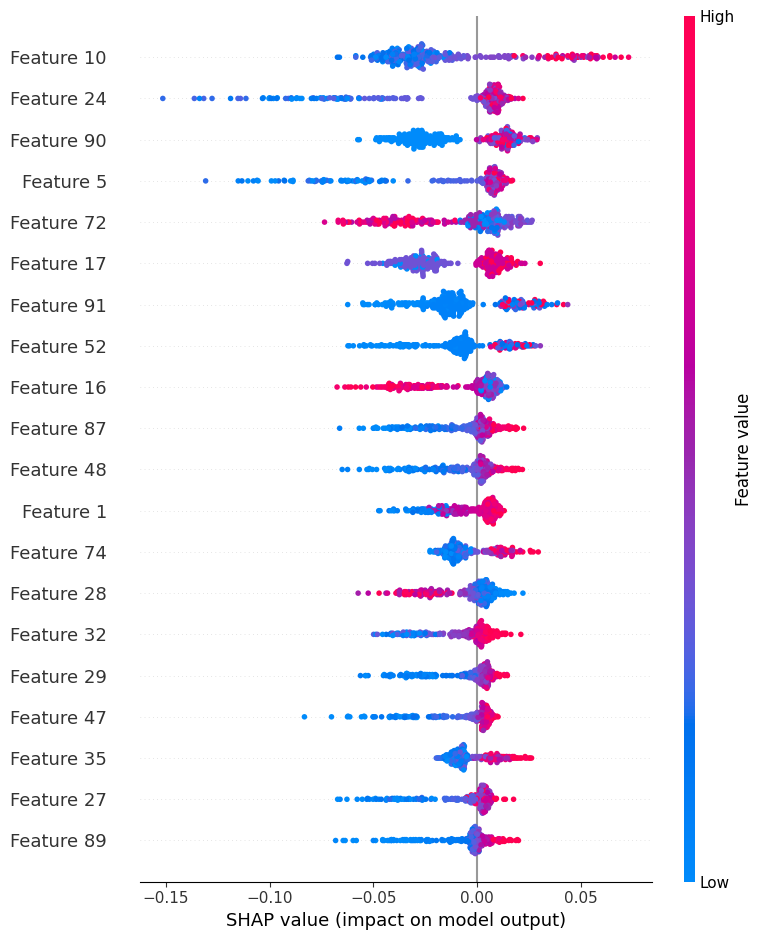

In [4]:
shap_values_pass = shap_values[:, :, 1]

print("shap_values_pass shape:", shap_values_pass.shape)

shap.summary_plot(shap_values_pass, X_test)

In [5]:
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values_pass[0],
    X_test[0]
)

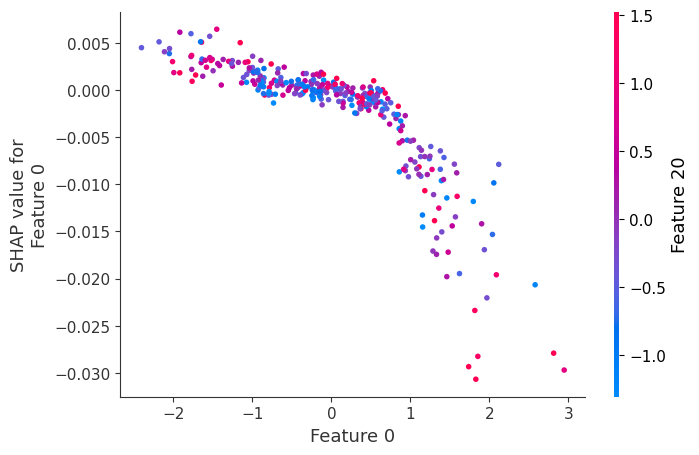

In [6]:
shap.dependence_plot(0, shap_values_pass, X_test)

In [7]:
import pandas as pd
import numpy as np

mean_shap = np.abs(shap_values_pass).mean(axis=0)
summary_df = pd.DataFrame({
    'feature_index': range(len(mean_shap)),
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False).head(20)

print("=== SUMMARY PLOT — Top 20 Features ===")
print(summary_df.to_string(index=False))


chip_idx = 0
force_df = pd.DataFrame({
    'feature_index': range(X_test.shape[1]),
    'shap_value': shap_values_pass[chip_idx],
    'feature_value': X_test[chip_idx]
}).sort_values('shap_value', ascending=False)

print("\n=== FORCE PLOT — Chip 0 (Top 10 pushing Pass) ===")
print(force_df.head(10).to_string(index=False))
print("\n=== FORCE PLOT — Chip 0 (Top 10 pushing Fail) ===")
print(force_df.tail(10).to_string(index=False))

top_feature_idx = summary_df.iloc[0]['feature_index']
dep_df = pd.DataFrame({
    'feature_value': X_test[:, int(top_feature_idx)],
    'shap_value': shap_values_pass[:, int(top_feature_idx)]
})

print(f"\n=== DEPENDENCE PLOT — Feature {int(top_feature_idx)} ===")
print(dep_df.describe().to_string())
print("\nSample of 10 rows:")
print(dep_df.sample(10, random_state=69).to_string(index=False))

print(f"\n=== BASELINE ===")
print(f"Expected value (base rate for Pass): {explainer.expected_value[1]:.4f}")
print(f"Actual Pass rate in test set: {y_test.mean():.4f}")

=== SUMMARY PLOT — Top 20 Features ===
 feature_index  mean_abs_shap
            10       0.032146
            24       0.024848
            90       0.021863
             5       0.021729
            72       0.020221
            17       0.019734
            91       0.019521
            52       0.015429
            16       0.014709
            87       0.011818
            48       0.011467
             1       0.011270
            74       0.011134
            28       0.010547
            32       0.010490
            29       0.010132
            47       0.009869
            35       0.009704
            27       0.009477
            89       0.009112

=== FORCE PLOT — Chip 0 (Top 10 pushing Pass) ===
 feature_index  shap_value  feature_value
            55    0.018757       2.256869
            74    0.017031       2.673684
            35    0.011414       2.280291
            68    0.008700       1.358355
            47    0.006925       0.458902
            81    0.005826  

In [8]:
# Finding most "confident" chips — highest absolute total SHAP
total_shap = np.abs(shap_values_pass).sum(axis=1)
print("Top 10 most 'opinionated' chips:")
top_chips = pd.DataFrame({
    'chip_index': range(len(total_shap)),
    'total_abs_shap': total_shap,
    'actual_label': y_test,
    'predicted_prob': rf_model.predict_proba(X_test)[:, 1]
}).sort_values('total_abs_shap', ascending=False).head(10)
print(top_chips.to_string(index=False))

Top 10 most 'opinionated' chips:
 chip_index  total_abs_shap  actual_label  predicted_prob
        233        0.694345             0        0.230063
         84        0.690475             0        0.196960
        179        0.676336             0        0.258000
         80        0.668517             0        0.360804
         97        0.664266             0        0.260650
        152        0.663052             0        0.180579
        157        0.653707             0        0.250399
         71        0.649605             0        0.212952
        184        0.646933             0        0.183178
         92        0.645314             0        0.218924


In [9]:
# Interesting chips across different scenarios
results = pd.DataFrame({
    'chip_index': range(len(y_test)),
    'total_abs_shap': total_shap,
    'actual_label': y_test,
    'predicted_prob': rf_model.predict_proba(X_test)[:, 1]
})

# Scenario A: True Positives
tp = results[(results['actual_label'] == 1) & (results['predicted_prob'] >= 0.5)]
print(f"=== Scenario A: True Positives ({len(tp)} chips) ===")
print(tp.sort_values('total_abs_shap', ascending=False).head(5).to_string(index=False))

# Scenario B: False Negatives
fn = results[(results['actual_label'] == 1) & (results['predicted_prob'] < 0.5)]
print(f"\n=== Scenario B: False Negatives ({len(fn)} chips) ===")
print(fn.sort_values('total_abs_shap', ascending=False).head(5).to_string(index=False))

# Scenario C: False Positives
fp = results[(results['actual_label'] == 0) & (results['predicted_prob'] >= 0.5)]
print(f"\n=== Scenario C: False Positives ({len(fp)} chips) ===")
print(fp.sort_values('total_abs_shap', ascending=False).head(5).to_string(index=False))

=== Scenario A: True Positives (6 chips) ===
 chip_index  total_abs_shap  actual_label  predicted_prob
        137        0.623546             1        0.513507
        304        0.622183             1        0.625615
        243        0.612386             1        0.566881
         81        0.584239             1        0.507769
        225        0.574601             1        0.623228

=== Scenario B: False Negatives (15 chips) ===
 chip_index  total_abs_shap  actual_label  predicted_prob
        244        0.643688             1        0.316261
        210        0.631053             1        0.266961
        251        0.623407             1        0.396286
        103        0.609281             1        0.205695
        285        0.606190             1        0.306990

=== Scenario C: False Positives (11 chips) ===
 chip_index  total_abs_shap  actual_label  predicted_prob
        134        0.644235             0        0.514875
         11        0.599499             0      

In [10]:
chip_idx = 304

force_df = pd.DataFrame({
    'feature_index': range(X_test.shape[1]),
    'shap_value': shap_values_pass[chip_idx],
    'feature_value': X_test[chip_idx]
}).sort_values('shap_value', ascending=False)

print(f"=== FORCE PLOT — Chip {chip_idx} (True Positive, prob={0.625:.3f}) ===")
print(f"Base rate: {explainer.expected_value[1]:.4f}")
print(f"Sum of SHAP values: {shap_values_pass[chip_idx].sum():.4f}")

print("\nTop 10 features PUSHING toward Pass:")
print(force_df.head(10).to_string(index=False))

print("\nTop 10 features PUSHING toward Fail:")
print(force_df.tail(10).to_string(index=False))

=== FORCE PLOT — Chip 304 (True Positive, prob=0.625) ===
Base rate: 0.5000
Sum of SHAP values: 0.1256

Top 10 features PUSHING toward Pass:
 feature_index  shap_value  feature_value
            10    0.056602       1.566088
            91    0.041643       4.017395
            52    0.026336       4.549545
            74    0.025611       2.914048
            35    0.023868       2.797220
            55    0.019041       2.703218
             1    0.013070       4.608439
            58    0.012689       6.835838
             5    0.011966       0.177581
            16    0.011191      -0.514996

Top 10 features PUSHING toward Fail:
 feature_index  shap_value  feature_value
            26   -0.010135       1.953780
            48   -0.010863      -0.231508
            84   -0.011181      -0.290918
            44   -0.013050      -0.308549
            90   -0.013363      -0.849017
            66   -0.014446      -0.783734
            87   -0.014979      -0.188629
            65   -0.017

In [11]:
dep_df = pd.DataFrame({
    'feature_value': X_test[:, 10],
    'shap_value': shap_values_pass[:, 10],
    'actual_label': y_test
})

print("=== DEPENDENCE PLOT — Feature 10 ===")
print(dep_df.describe().to_string())

print("\n--- Pass chips (actual) ---")
print(dep_df[dep_df['actual_label'] == 1].describe().to_string())

print("\n--- Fail chips (actual) ---")
print(dep_df[dep_df['actual_label'] == 0].describe().to_string())

=== DEPENDENCE PLOT — Feature 10 ===
       feature_value  shap_value  actual_label
count     314.000000  314.000000    314.000000
mean       -0.031784   -0.015014      0.066879
std         0.830426    0.031759      0.250211
min        -2.133022   -0.067311      0.000000
25%        -0.505174   -0.036819      0.000000
50%        -0.200712   -0.026747      0.000000
75%         0.144163   -0.006472      0.000000
max         3.396398    0.073006      1.000000

--- Pass chips (actual) ---
       feature_value  shap_value  actual_label
count      21.000000   21.000000          21.0
mean        0.477189    0.017576           1.0
std         0.887412    0.038364           0.0
min        -0.943035   -0.048963           1.0
25%         0.012199   -0.010256           1.0
50%         0.361560    0.029290           1.0
75%         0.958921    0.050011           1.0
max         2.132443    0.073006           1.0

--- Fail chips (actual) ---
       feature_value  shap_value  actual_label
count     29

In [12]:
summary_df.to_csv('../reports/shap_summary.csv', index=False)

force_df.to_csv('../reports/shap_force_chip304.csv', index=False)

dep_df.to_csv('../reports/shap_dependence_feature10.csv', index=False)

#all SHAP reports saved

In [13]:
shap.summary_plot(shap_values_pass, X_test, show=False)
plt.savefig('../reports/shap_summary_plot.png', bbox_inches='tight', dpi=150)
plt.close()
print("Summary plot saved.")

shap.force_plot(
    explainer.expected_value[1],
    shap_values_pass[304],
    X_test[304],
    matplotlib=True,
    show=False
)
plt.savefig('../reports/shap_force_chip304.png', bbox_inches='tight', dpi=150)
plt.close()
print("Force plot saved.")

shap.dependence_plot(10, shap_values_pass, X_test, show=False)
plt.savefig('../reports/shap_dependence_feature10.png', bbox_inches='tight', dpi=150)
plt.close()
print("Dependence plot saved.")

Summary plot saved.
Force plot saved.
Dependence plot saved.
